# Dummy Baseline and Logistic Regression — src Refactor

This notebook trains the first two classification models while importing reusable data, model, metric, and plotting utilities from `src/`.

The notebook remains responsible for the **experiment and interpretation**; reusable implementation is kept in `src/`.

## 1. Bootstrap project imports

In [1]:
from pathlib import Path
import sys

# Make imports work whether VS Code starts the notebook from project root
# or from the notebooks/ directory.
cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_DIR = cwd
elif (cwd.parent / "src").exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing src/. "
        "Open this notebook from the clinical-outcome-prediction project."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project root:", PROJECT_DIR)
print("Python:", sys.executable)

Project root: C:\Projects\clinical-outcome-prediction
Python: c:\Projects\clinical-outcome-prediction\.venv\Scripts\python.exe


## 2. Imports

In [2]:
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from src.config import (
    MODELS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    PREPROCESSOR_PATH,
    FEATURE_CONFIG_PATH,
)
from src.data import (
    load_modeling_splits,
    load_feature_config,
    validate_cohort,
    validate_patient_split,
)
from src.models import train_logistic_model
from src.evaluation import (
    classification_metrics,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
)

DEFAULT_THRESHOLD = 0.50

DUMMY_MODEL_PATH = MODELS_DIR / "dummy_baseline.joblib"
LOGISTIC_MODEL_PATH = MODELS_DIR / "logistic_regression.joblib"

for directory in [
    MODELS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

## 3. Load and validate data

In [3]:
train_df, validation_df, test_df = load_modeling_splits()
feature_config = load_feature_config()
preprocessor = joblib.load(PREPROCESSOR_PATH)

target_column = feature_config["target_column"]
feature_columns = feature_config["retained_feature_columns"]

for dataframe, name in [
    (train_df, "train"),
    (validation_df, "validation"),
    (test_df, "test"),
]:
    validate_cohort(
        dataframe,
        target_column=target_column,
        dataframe_name=name,
    )

validate_patient_split(
    train_df,
    validation_df,
    test_df,
)

X_train = train_df[feature_columns].copy()
X_validation = validation_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df[target_column].copy()
y_validation = validation_df[target_column].copy()
y_test = test_df[target_column].copy()

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)
print("Training mortality:", round(float(y_train.mean()), 4))

Train: (89, 66)
Validation: (20, 66)
Test: (19, 66)
Training mortality: 0.1236


## 4. Train dummy baseline

In [4]:
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=42,
            ),
        ),
    ]
)

dummy_model.fit(
    X_train,
    y_train,
)

dummy_validation_probability = (
    dummy_model.predict_proba(
        X_validation
    )[:, 1]
)

dummy_metrics = classification_metrics(
    y_validation,
    dummy_validation_probability,
    threshold=DEFAULT_THRESHOLD,
)

pd.Series(
    dummy_metrics,
    name="Dummy baseline",
)

auroc                         0.5
auprc                         0.1
threshold                     0.5
accuracy                      0.9
precision_ppv                 0.0
recall_sensitivity            0.0
specificity                   1.0
negative_predictive_value     0.9
f1_score                      0.0
true_negatives               18.0
false_positives               0.0
false_negatives               2.0
true_positives                0.0
patients_flagged              0.0
flagged_percentage            0.0
Name: Dummy baseline, dtype: float64

## 5. Train Logistic Regression using src.models

In [5]:
logistic_model = train_logistic_model(
    preprocessor,
    X_train,
    y_train,
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
)

logistic_validation_probability = (
    logistic_model.predict_proba(
        X_validation
    )[:, 1]
)

logistic_metrics = classification_metrics(
    y_validation,
    logistic_validation_probability,
    threshold=DEFAULT_THRESHOLD,
)

pd.Series(
    logistic_metrics,
    name="Logistic Regression",
)

auroc                         0.361111
auprc                         0.133333
threshold                     0.500000
accuracy                      0.850000
precision_ppv                 0.000000
recall_sensitivity            0.000000
specificity                   0.944444
negative_predictive_value     0.894737
f1_score                      0.000000
true_negatives               17.000000
false_positives               1.000000
false_negatives               2.000000
true_positives                0.000000
patients_flagged              1.000000
flagged_percentage            0.050000
Name: Logistic Regression, dtype: float64

## 6. Validation comparison

In [6]:
validation_results = pd.DataFrame(
    [
        {
            "model": "Dummy baseline",
            **dummy_metrics,
        },
        {
            "model": "Logistic Regression",
            **logistic_metrics,
        },
    ]
).sort_values(
    ["auprc", "auroc"],
    ascending=False,
).reset_index(drop=True)

validation_results

,model,auroc,auprc,threshold,accuracy,precision_ppv,recall_sensitivity,specificity,negative_predictive_value,f1_score,true_negatives,false_positives,false_negatives,true_positives,patients_flagged,flagged_percentage
0,Logistic Regression,0.361111,0.133333,0.5,0.85,0.0,0.0,0.944444,0.894737,0.0,17,1,2,0,1,0.05
1,Dummy baseline,0.500000,0.100000,0.5,0.90,0.0,0.0,1.000000,0.900000,0.0,18,0,2,0,0,0.00


## 7. ROC and precision-recall curves

<Axes: title={'center': 'Validation ROC — Logistic Regression'}, xlabel='False Positive Rate (Positive label: 1)', ylabel='True Positive Rate (Positive label: 1)'>

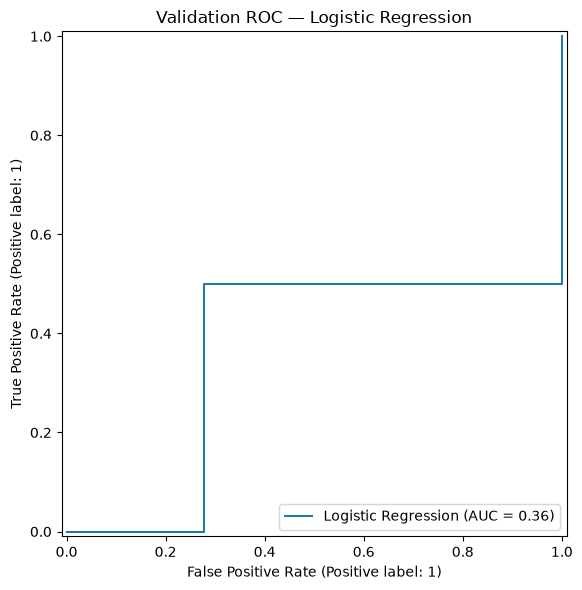

In [7]:
plot_roc_curve(
    y_validation,
    logistic_validation_probability,
    name="Logistic Regression",
    title="Validation ROC — Logistic Regression",
    save_path=FIGURES_DIR / "logistic_validation_roc.png",
)

<Axes: title={'center': 'Validation Precision-Recall — Logistic Regression'}, xlabel='Recall (Positive label: 1)', ylabel='Precision (Positive label: 1)'>

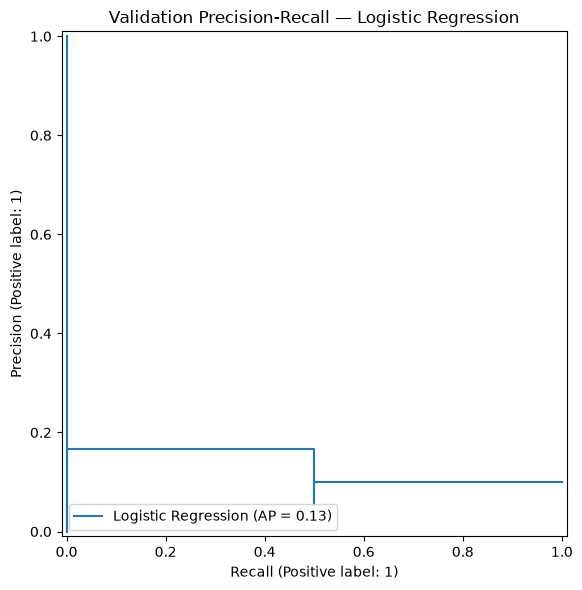

In [8]:
plot_precision_recall_curve(
    y_validation,
    logistic_validation_probability,
    name="Logistic Regression",
    title="Validation Precision-Recall — Logistic Regression",
    save_path=FIGURES_DIR / "logistic_validation_pr.png",
)

## 8. Confusion matrix at threshold 0.50

<Axes: title={'center': 'Logistic Regression Validation Confusion Matrix (threshold=0.50)'}, xlabel='Predicted label', ylabel='True label'>

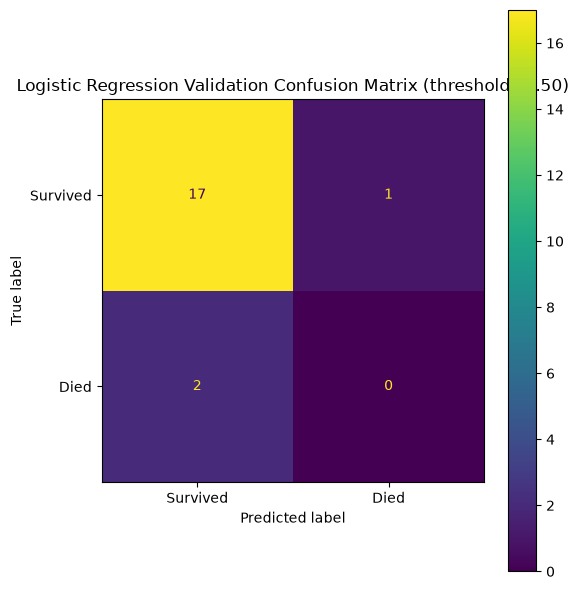

In [9]:
plot_confusion_matrix(
    y_validation,
    logistic_validation_probability,
    threshold=DEFAULT_THRESHOLD,
    title="Logistic Regression Validation Confusion Matrix",
    save_path=FIGURES_DIR / "logistic_validation_confusion_matrix.png",
)

## 9. Save models, metrics, and predictions

In [10]:
joblib.dump(
    dummy_model,
    DUMMY_MODEL_PATH,
)

joblib.dump(
    logistic_model,
    LOGISTIC_MODEL_PATH,
)

METRICS_PATH = TABLES_DIR / "baseline_logistic_validation_metrics.csv"
PREDICTIONS_PATH = PREDICTIONS_DIR / "baseline_logistic_validation_predictions.csv"

validation_results.to_csv(
    METRICS_PATH,
    index=False,
)

validation_predictions = validation_df[
    ["subject_id", "hadm_id", "stay_id", target_column]
].copy()

validation_predictions["dummy_probability"] = (
    dummy_validation_probability
)
validation_predictions["logistic_probability"] = (
    logistic_validation_probability
)

validation_predictions.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

print("Saved:", DUMMY_MODEL_PATH)
print("Saved:", LOGISTIC_MODEL_PATH)
print("Saved:", METRICS_PATH)
print("Saved:", PREDICTIONS_PATH)

Saved: C:\Projects\clinical-outcome-prediction\models\dummy_baseline.joblib
Saved: C:\Projects\clinical-outcome-prediction\models\logistic_regression.joblib
Saved: C:\Projects\clinical-outcome-prediction\results\tables\baseline_logistic_validation_metrics.csv
Saved: C:\Projects\clinical-outcome-prediction\results\predictions\baseline_logistic_validation_predictions.csv


## 10. Reload validation

In [11]:
reloaded_logistic = joblib.load(
    LOGISTIC_MODEL_PATH
)

reloaded_probability = (
    reloaded_logistic.predict_proba(
        X_validation
    )[:, 1]
)

assert np.allclose(
    reloaded_probability,
    logistic_validation_probability,
)

print("Saved Logistic Regression validation passed.")

Saved Logistic Regression validation passed.


## Notebook 6 summary

The reusable model construction and evaluation code now lives in `src/`.

Next: **Notebook 7 — Random Forest, XGBoost, cross-validation, tuning, and model selection**.